In [13]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import matplotlib.pyplot as plt

# Functions

### Seeds

In [14]:
def create_seed (number_of_required_seeds):
    base_seed_number = 100 #Random base number to generate seeds
    seed_dictionary = {}
    for i in range(1,number_of_required_seeds+1):
        seed_dictionary[i-1] = np.random.default_rng(seed = i + base_seed_number)   
    return seed_dictionary

### Random Walk With Mean Reversion

In [15]:
def random_walk (array,seed):
    threshold = 25
    Speed_of_reversion = 0.15333
    for i in range(1, np.size(array)):
        reversion_value = array[0]
        array[i] = (array[i-1] 
                    + Speed_of_reversion 
                    *(reversion_value - array[i-1]) 
                    + rng[seed].integers(-threshold,threshold))
    return array

In [16]:
data = pd.DataFrame()

# Rate Generation

In [17]:
# DATA
I = 2 # Number of wells
months = 36 # Time variable 
initial_rate = 500 #Initial rate 

In [18]:
rng = create_seed(I) #Seed dictionary creation

In [19]:
rates_of_injectors = np.zeros([I,months])

for i in range(I):
    
    threshold = 50 
    
    for injector in rates_of_injectors: #Initial rate generation
        injector[0] = (initial_rate 
                       + rng[i].integers(-threshold,threshold))
        
    rates_of_injectors[i] = random_walk(rates_of_injectors[i],i) #Random Walk mean controlled

## Results

In [20]:
data = pd.DataFrame(index = np.arange(months)) #Data frame generation

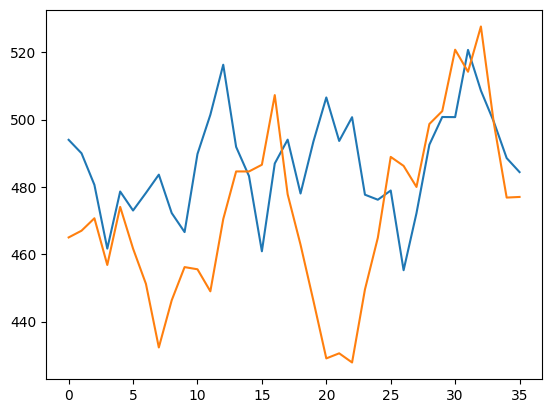

In [21]:
for i in range(I):
    data['I_'f"{i+1}"] = rates_of_injectors[i]
    plt.plot(rates_of_injectors[i])

In [22]:
data

,I_1,I_2
0,494.000000,465.000000
1,490.000000,467.000000
2,480.620030,470.693340
3,461.678291,456.820380
4,478.640888,474.074561
5,473.002611,461.683159
6,478.228851,451.191730
7,483.653751,432.308952
8,472.246851,446.321470
9,466.588972,456.185449


In [23]:
data.corr()

,I_1,I_2
I_1,1.000000,0.198338
I_2,0.198338,1.000000
